# Supp Fig 2 — strict-confidence mode

Reproduces **SuppFig2** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 2 — strict mode calibration + slope + spatial
**🔴 heavy (GPU / multi-GB / long)** · source: `strict_mode_external_primary.ipynb cells 1,3,5,16,18,19`

In [ ]:
%matplotlib inline
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path[:0] = [str(REPO_ROOT / 'scripts'), str(NB)]
import gxd_split_config; importlib.reload(gxd_split_config)
from gxd_split_config import GXD_PRIMARY_SAMPLES, ANNOT_DIR

import spatnic

CKPT = 'tumor_normal'
ORIGINAL_H5AD = BACKUP_ROOT / 'integrate_adata_filtered.h5ad'

OUT_DIR = COMP / 'strict_mode'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAL = {'Tumor': '#F4B183', 'Normal': '#9DC3E6', 'ambiguous': '#666666'}
LABELS = ['Normal', 'Tumor']

print('SAMPLES =', GXD_PRIMARY_SAMPLES)
print('OUT_DIR =', OUT_DIR)


def primary_test_scores():
    """Reproduce the train_spatnic primary held-out test set, predict, return (y_true, score)."""
    a = ad.read_h5ad(ORIGINAL_H5AD)
    a = a[a.obs['Cell_type_integrate'] != 'Tumor-infiltrating immune cell'].copy()
    a.obs['Major_cluster'] = a.obs['Cell_type_integrate'].replace({
        'Endothelial': 'Stromal', 'CAF': 'Stromal', 'Fibroblast': 'Stromal',
        'Tumor': 'Epithelial',
    })
    a.obs['Major_cluster_pathol'] = a.obs['Cell_type_integrate'].replace({
        'Endothelial': 'Stromal', 'CAF': 'Stromal', 'Fibroblast': 'Stromal',
        'Epithelial': 'Normal',
    })
    a_epi = a[a.obs['Major_cluster'] == 'Epithelial'].copy()
    a_epi.obs['label'] = a_epi.obs['Major_cluster_pathol'].map({'Normal': 0, 'Tumor': 1})
    a_epi = a_epi[a_epi.obs['label'].notna()].copy()
    a_epi.obs['label'] = a_epi.obs['label'].astype(int)
    sampled = []
    for lab in sorted(a_epi.obs['label'].unique()):
        pool = a_epi.obs[a_epi.obs['label'] == lab].index
        sampled.append(pd.Series(pool).sample(n=min(244509, len(pool)), random_state=42).values)
    sel = np.concatenate(sampled)
    a_bal = a_epi[sel].copy()
    idx = np.arange(a_bal.n_obs)
    _, idx_te = train_test_split(idx, test_size=0.2,
                                 stratify=a_bal.obs['label'].values, random_state=42)
    a_te = a_bal[idx_te].copy()
    spatnic.predict(a_te, model=CKPT, key_added='_p', score_key_added='_s')
    y = a_te.obs['Major_cluster_pathol'].astype(str).values
    s = a_te.obs['_s'].astype(float).values
    return y, s

y_cal, s_cal = primary_test_scores()
tumor_scores  = s_cal[y_cal == 'Tumor']
normal_scores = s_cal[y_cal == 'Normal']
T_LOW  = float(np.percentile(tumor_scores,  1.0))
T_HIGH = float(np.percentile(normal_scores, 99.0))
print(f'T_low  = {T_LOW:.4f}  (sens >= 99%)')
print(f'T_high = {T_HIGH:.4f}  (spec >= 99%)')
print(f'ambiguous band [{T_LOW:.4f}, {T_HIGH:.4f}], width = {T_HIGH-T_LOW:.4f}')


def _strict(s, lo=T_LOW, hi=T_HIGH):
    if s >= hi: return 'Tumor'
    if s <  lo: return 'Normal'
    return 'ambiguous'

def _tp_tn_fp_fn(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn))

rows = []
for sid in GXD_PRIMARY_SAMPLES:
    p = ANNOT_DIR / f'gxd_xenium_{sid}_annotated.h5ad'
    a = ad.read_h5ad(p)
    spatnic.predict(a, model=CKPT,
                    key_added='spatnic_pred', score_key_added='spatnic_score')
    s = a.obs['spatnic_score'].astype(float).values
    y = a.obs['true_label_str'].astype(str).values

    bin_pred = np.where(s >= 0.5, 'Tumor', 'Normal')
    bin_cm   = _tp_tn_fp_fn(y, bin_pred)

    strict = np.array([_strict(v) for v in s])
    kept   = (strict != 'ambiguous')
    str_cm = _tp_tn_fp_fn(y[kept], strict[kept])
    n_amb_T = int(((strict == 'ambiguous') & (y == 'Tumor')).sum())
    n_amb_N = int(((strict == 'ambiguous') & (y == 'Normal')).sum())

    n = a.n_obs
    rows.append(dict(
        sample=sid, n_cells=n,
        n_Tumor_gt=int((y == 'Tumor').sum()),
        n_Normal_gt=int((y == 'Normal').sum()),
        bin_TP=bin_cm['TP'], bin_TN=bin_cm['TN'],
        bin_FP=bin_cm['FP'], bin_FN=bin_cm['FN'],
        str_TP=str_cm['TP'], str_TN=str_cm['TN'],
        str_FP=str_cm['FP'], str_FN=str_cm['FN'],
        amb_T=n_amb_T, amb_N=n_amb_N,
        n_kept=int(kept.sum()), n_ambiguous=int((~kept).sum()),
    ))
    print(f'  {sid}: n={n:,}, kept={int(kept.sum()):,} '
          f'({100*kept.mean():.1f}%), ambiguous={int((~kept).sum()):,}')

df = pd.DataFrame(rows).set_index('sample')
df.loc['ALL'] = df.sum(numeric_only=True)
df


# ── §6b. Per-sample before→after (binary → strict): FN rate, FP rate, cell count ──
# Slopegraph: one line per sample connecting its binary value to its strict value.
# FN%/FP% use the kept-class denominator for strict (same convention as §5).
samp = [s for s in df.index if s != 'ALL']
d = df.loc[samp]

n_pos      = d['n_Tumor_gt'].astype(float)
n_neg      = d['n_Normal_gt'].astype(float)
n_pos_kept = (d['n_Tumor_gt']  - d['amb_T']).astype(float)
n_neg_kept = (d['n_Normal_gt'] - d['amb_N']).astype(float)

slope = pd.DataFrame(index=samp)
slope['FN_binary']    = 100 * d['bin_FN'] / n_pos
slope['FN_strict']    = 100 * d['str_FN'] / n_pos_kept
slope['FP_binary']    = 100 * d['bin_FP'] / n_neg
slope['FP_strict']    = 100 * d['str_FP'] / n_neg_kept
slope['cells_binary'] = d['n_cells'].astype(float)   # all cells classified
slope['cells_strict'] = d['n_kept'].astype(float)    # cells kept (ambiguous dropped)

cmap = plt.colormaps.get_cmap('tab10')
colors = {sid: cmap(i % 10) for i, sid in enumerate(samp)}

panels = [
    ('FN rate',  'FN_binary', 'FN_strict', 'FN rate  (FN / kept positives, %)'),
    ('FP rate',  'FP_binary', 'FP_strict', 'FP rate  (FP / kept negatives, %)'),
    ('# cells',  'cells_binary', 'cells_strict', 'cells classified (#)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, (short, cb, cs, ylab) in zip(axes, panels):
    for sid in samp:
        yb, ys = slope.loc[sid, cb], slope.loc[sid, cs]
        ax.plot([0, 1], [yb, ys], '-o', color=colors[sid], lw=2.0, ms=7)
        ax.annotate(sid, (1, ys), textcoords='offset points', xytext=(6, 0),
                    va='center', fontsize=9, color=colors[sid], fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Binary\n@ 0.5', 'Strict\n(kept)'], fontsize=11)
    ax.set_xlim(-0.25, 1.45)
    ax.set_ylabel(ylab, fontsize=12)
    ax.set_title(short, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[2].ticklabel_format(axis='y', style='plain')   # cell counts shown in full

fig.suptitle('Binary → Strict per GxD primary sample: FN rate, FP rate, cells classified\n'
             f'(ambiguous band [{T_LOW:.3f}, {T_HIGH:.3f}];  one line = one sample)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
out = OUT_DIR / 'strict_mode_external_primary_slope.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'saved: {out}')

slope_out = slope.round(2)
slope_out.to_csv(OUT_DIR / 'strict_mode_external_primary_slope.csv')
print('saved: strict_mode_external_primary_slope.csv')
plt.show()
slope_out


import gxd_he_overlay; importlib.reload(gxd_he_overlay)
from gxd_he_overlay import warp_he_to_dapi

# Cache adatas + warped H&E so we can reuse across per-sample saves + combined grid
_per_sample = {}
for sid in GXD_PRIMARY_SAMPLES:
    p = ANNOT_DIR / f'gxd_xenium_{sid}_annotated.h5ad'
    a = ad.read_h5ad(p)
    spatnic.predict(a, model=CKPT,
                    key_added='spatnic_pred', score_key_added='spatnic_score')
    s = a.obs['spatnic_score'].astype(float).values
    a.obs['binary_pred'] = np.where(s >= 0.5, 'Tumor', 'Normal')
    a.obs['strict_label'] = np.array([_strict(v) for v in s])
    try:
        he, w_um, h_um = warp_he_to_dapi(sid)
    except Exception as exc:
        print(f'  [he] {sid}: warp failed ({exc}); no H&E underlay')
        he, w_um, h_um = None, None, None
    _per_sample[sid] = dict(a=a, he=he, w_um=w_um, h_um=h_um)
    print(f'  {sid}: cached  (cells={a.n_obs:,}, he={"yes" if he is not None else "no"})')


def _draw_panel(ax, a, he, w_um, h_um, label_col, palette, draw_order, title,
                pt_size=1.6, he_alpha=0.85):
    if he is not None:
        ax.imshow(he, extent=[0, w_um, h_um, 0], interpolation='bilinear',
                  alpha=he_alpha, zorder=0)
    xy = np.asarray(a.obsm['spatial'], float)
    labs = a.obs[label_col].astype(str).values
    for lab in draw_order:
        m = (labs == lab)
        if not m.any():
            continue
        ax.scatter(xy[m, 0], xy[m, 1], s=pt_size, c=palette[lab],
                   alpha=0.85, linewidths=0, rasterized=True, zorder=2,
                   label=f'{lab} (n={int(m.sum()):,})')
    x0, x1 = xy[:, 0].min(), xy[:, 0].max()
    y0, y1 = xy[:, 1].min(), xy[:, 1].max()
    pad = 0.02 * max(x1 - x0, y1 - y0)
    ax.set_xlim(x0 - pad, x1 + pad); ax.set_ylim(y1 + pad, y0 - pad)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, markerscale=4, framealpha=0.92)

BIN_PAL = {'Tumor': '#F4B183', 'Normal': '#9DC3E6'}
GT_PAL  = {'Tumor': '#F4B183', 'Normal': '#9DC3E6'}

# Per-sample 1×3 figure
for sid in GXD_PRIMARY_SAMPLES:
    rec = _per_sample[sid]
    a, he, w_um, h_um = rec['a'], rec['he'], rec['w_um'], rec['h_um']

    xy = np.asarray(a.obsm['spatial'], float)
    aspect = max(1e-6, (xy[:, 0].max() - xy[:, 0].min())
                          / (xy[:, 1].max() - xy[:, 1].min()))
    panel_h = 7.0
    panel_w = max(4.5, min(9.0, panel_h * aspect))
    fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3 + 0.8, panel_h))

    _draw_panel(axes[0], a, he, w_um, h_um,
                'true_label_str', GT_PAL,
                draw_order=['Normal', 'Tumor'],
                title=f'{sid}  Ground truth')
    _draw_panel(axes[1], a, he, w_um, h_um,
                'binary_pred', BIN_PAL,
                draw_order=['Normal', 'Tumor'],
                title=f'{sid}  Binary @ 0.5  (kept=100%)')
    _draw_panel(axes[2], a, he, w_um, h_um,
                'strict_label', PAL,
                draw_order=['Normal', 'ambiguous', 'Tumor'],
                title=(f'{sid}  Strict mode  '
                       f'(kept={100*(a.obs["strict_label"]!="ambiguous").mean():.1f}%)'))

    fig.suptitle(f'{sid}: GT vs binary vs strict on H&E', fontsize=14, fontweight='bold')
    fig.tight_layout()
    out = OUT_DIR / f'strict_mode_external_primary_{sid}_spatial.png'
    fig.savefig(out, dpi=140, bbox_inches='tight')
    print(f'saved: {out}')
    plt.show()

## Published result (reference)
Embedded reference output; the code above regenerates it.

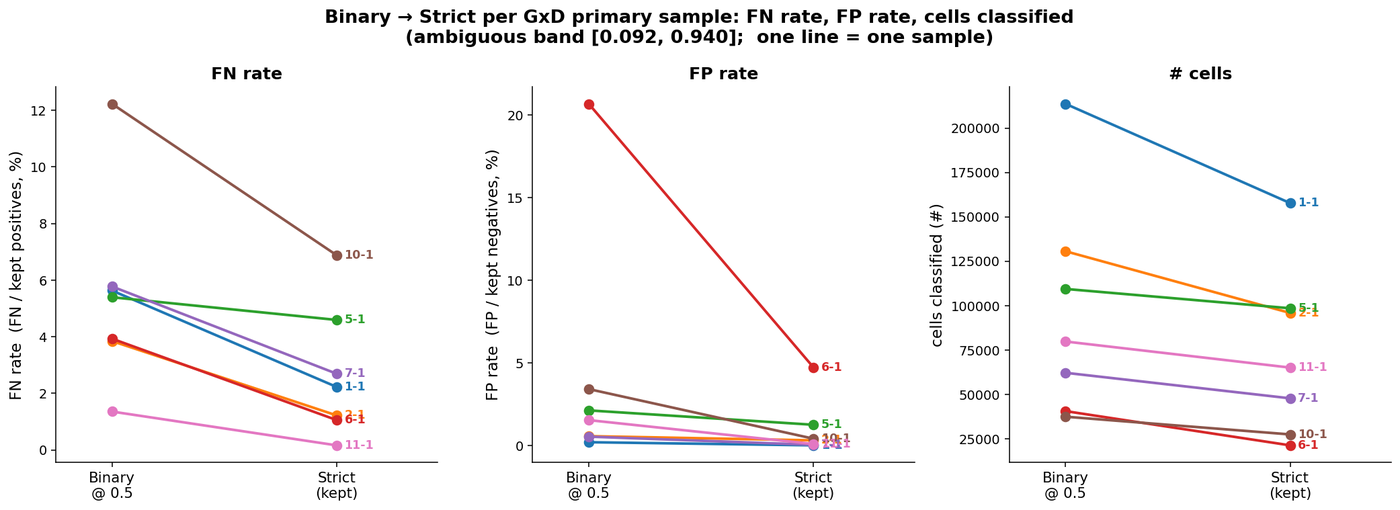

In [ ]:
# Default→Strict FN/FP rate & cell count
Image(str(COMP / "strict_mode/strict_mode_external_primary_slope.png"))